# Red Neuronal Optimizada para Predicción de Diabetes

Este notebook implementa una red neuronal con PyTorch para predecir valores objetivo del dataset de diabetes. Incluye:
- Optimización de hiperparámetros con Optuna
- Análisis de interpretabilidad con SHAP
- Comparación con Random Forest y XGBoost

## 1. Configuración Inicial e Importación de Librerías

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import optuna
import sys
import logging
import shap
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

# Configurar logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger()

# Fijar semillas para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Configuración mejorada para recursos
torch.set_num_threads(8)  # Aumentar a 8 hilos
torch.backends.cudnn.enabled = False

/Users/leosantucho/miniconda3/envs/machine-learning/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Carga y Preparación de Datos

Cargamos el dataset de diabetes, dividimos en conjuntos de entrenamiento, validación y prueba, y aplicamos normalización.

In [2]:
# Cargar y preparar datos
try:
    data = load_diabetes()
    X, y = data.data, data.target
    feature_names = data.feature_names
    
    # Dividir datos
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
    
    # Escalar
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)
    
    # Convertir a tensores
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)
    
    logger.info("Datos preparados:")
    logger.info(f"- Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")
    logger.info(f"- Features: {X_train.shape[1]} (sin transformación polinómica)")
    
except Exception as e:
    logger.error(f"Error preparando datos: {str(e)}")
    sys.exit(1)

2025-07-29 08:35:01,232 - INFO - Datos preparados:
2025-07-29 08:35:01,237 - INFO - - Train: 282, Val: 71, Test: 89
2025-07-29 08:35:01,248 - INFO - - Features: 10 (sin transformación polinómica)


## 3. Definición de la Arquitectura de Red Neuronal

Implementamos una red neuronal flexible con:
- Número variable de capas ocultas
- Batch normalization opcional
- Dropout para regularización
- Inicialización mejorada de pesos

In [3]:
# Red neuronal mejorada con mayor capacidad
class EnhancedNN(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size, activation, dropout, use_batchnorm):
        super(EnhancedNN, self).__init__()
        layers = []
        prev_size = input_size
        
        # Hasta 3 capas ocultas con más neuronas
        for i, size in enumerate(hidden_sizes):
            layers.append(nn.Linear(prev_size, size))
            
            # Batch normalization opcional
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(size))
                
            layers.append(nn.ReLU() if activation == 'relu' else nn.Tanh())
            layers.append(nn.Dropout(dropout))
            prev_size = size
        
        layers.append(nn.Linear(prev_size, output_size))
        self.net = nn.Sequential(*layers)
        
        # Inicialización mejorada
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_normal_(layer.weight, nonlinearity='relu' if activation == 'relu' else 'tanh')
                nn.init.constant_(layer.bias, 0.01)
    
    def forward(self, x):
        return self.net(x)

## 4. Optimización de Hiperparámetros con Optuna

Definimos la función objetivo para optimizar:
- Número de capas y neuronas
- Learning rate
- Función de activación
- Tamaño de batch
- Dropout
- Número de épocas
- Uso de batch normalization

In [4]:
# Función objetivo optimizada
def objective(trial):
    try:
        # Hiperparámetros con rangos ampliados
        n_layers = trial.suggest_int('n_layers', 1, 3)  # Hasta 3 capas
        hidden_units = [trial.suggest_int(f'units_{i}', 32, 128) for i in range(n_layers)]  # 32-128 neuronas
        
        lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
        activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
        batch_size = trial.suggest_int('batch_size', 32, 128)  # Batch más grande
        dropout = trial.suggest_float('dropout', 0.1, 0.5)
        epochs = trial.suggest_int('epochs', 30, 100)  # Más épocas
        use_batchnorm = trial.suggest_categorical('use_batchnorm', [True, False])
        
        # Crear modelo mejorado
        model = EnhancedNN(
            input_size=X_train.shape[1],
            hidden_sizes=hidden_units,
            output_size=1,
            activation=activation,
            dropout=dropout,
            use_batchnorm=use_batchnorm
        )
        
        # Optimizador con regularización
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        criterion = nn.MSELoss()
        
        # Entrenamiento
        best_val_loss = float('inf')
        patience_counter = 0
        max_patience = 7
        
        for epoch in range(epochs):
            model.train()
            epoch_loss = 0
            batch_count = 0
            
            # Mini-batches
            for i in range(0, len(X_train_t), batch_size):
                end = min(i + batch_size, len(X_train_t))
                X_batch = X_train_t[i:end]
                y_batch = y_train_t[i:end]
                
                optimizer.zero_grad()
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                
                epoch_loss += loss.item()
                batch_count += 1
            
            # Validación
            model.eval()
            with torch.no_grad():
                val_outputs = model(X_val_t)
                val_loss = criterion(val_outputs, y_val_t).item()
            
            # Early stopping con paciencia
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= max_patience:
                    break
        
        return best_val_loss
    
    except Exception as e:
        logger.warning(f"Trial {trial.number} fallido: {str(e)}")
        return float('inf')

### Ejecutar la Optimización con Optuna

In [5]:
# Optimización con Optuna (30 trials)
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner()
)

try:
    logger.info("Comenzando optimización con Optuna (30 trials)...")
    study.optimize(objective, n_trials=30, show_progress_bar=True)
except Exception as e:
    logger.error(f"Error en Optuna: {str(e)}")
    sys.exit(1)

# Obtener mejores parámetros
if not study.best_trial:
    logger.error("No se completaron trials exitosos")
    sys.exit(1)

best_params = study.best_trial.params
logger.info("\nMejores hiperparámetros:")
for k, v in best_params.items():
    logger.info(f"{k}: {v}")

[I 2025-07-29 08:35:12,295] A new study created in memory with name: no-name-da40fe0b-69cb-4f78-b28c-0d3e7c79d1ac
2025-07-29 08:35:12,298 - INFO - Comenzando optimización con Optuna (30 trials)...
Best trial: 0. Best value: 6643.33:   7%|▋         | 2/30 [00:01<00:19,  1.45it/s]

[I 2025-07-29 08:35:13,754] Trial 0 finished with value: 6643.33349609375 and parameters: {'n_layers': 2, 'units_0': 124, 'units_1': 103, 'lr': 0.0015751320499779737, 'activation': 'relu', 'batch_size': 37, 'dropout': 0.4464704583099741, 'epochs': 72, 'use_batchnorm': True}. Best is trial 0 with value: 6643.33349609375.
[I 2025-07-29 08:35:13,913] Trial 1 finished with value: 32819.95703125 and parameters: {'n_layers': 3, 'units_0': 112, 'units_1': 52, 'units_2': 49, 'lr': 0.00023270677083837802, 'activation': 'tanh', 'batch_size': 73, 'dropout': 0.21649165607921678, 'epochs': 73, 'use_batchnorm': False}. Best is trial 0 with value: 6643.33349609375.


Best trial: 3. Best value: 3143.29:  13%|█▎        | 4/30 [00:01<00:07,  3.26it/s]

[I 2025-07-29 08:35:14,052] Trial 2 finished with value: 32270.775390625 and parameters: {'n_layers': 2, 'units_0': 76, 'units_1': 108, 'lr': 0.00025081156860452336, 'activation': 'tanh', 'batch_size': 36, 'dropout': 0.34301794076057535, 'epochs': 42, 'use_batchnorm': False}. Best is trial 0 with value: 6643.33349609375.
[I 2025-07-29 08:35:14,158] Trial 3 finished with value: 3143.2900390625 and parameters: {'n_layers': 3, 'units_0': 110, 'units_1': 61, 'units_2': 41, 'lr': 0.0023359635026261607, 'activation': 'relu', 'batch_size': 80, 'dropout': 0.11375540844608736, 'epochs': 94, 'use_batchnorm': False}. Best is trial 3 with value: 3143.2900390625.
[I 2025-07-29 08:35:14,236] Trial 4 finished with value: 30914.728515625 and parameters: {'n_layers': 1, 'units_0': 82, 'lr': 0.0012399967836846098, 'activation': 'tanh', 'batch_size': 107, 'dropout': 0.4757995766256757, 'epochs': 93, 'use_batchnorm': False}. Best is trial 3 with value: 3143.2900390625.


Best trial: 3. Best value: 3143.29:  23%|██▎       | 7/30 [00:02<00:03,  6.01it/s]

...

[I 2025-07-29 08:35:17,788] Trial 24 finished with value: 3943.703857421875 and parameters: {'n_layers': 3, 'units_0': 87, 'units_1': 116, 'units_2': 86, 'lr': 0.0003761582962624025, 'activation': 'relu', 'batch_size': 67, 'dropout': 0.20059318697566883, 'epochs': 79, 'use_batchnorm': False}. Best is trial 3 with value: 3143.2900390625.
[I 2025-07-29 08:35:17,916] Trial 25 finished with value: 3583.96337890625 and parameters: {'n_layers': 3, 'units_0': 100, 'units_1': 77, 'units_2': 68, 'lr': 0.0012141082236449955, 'activation': 'relu', 'batch_size': 91, 'dropout': 0.27348221377385273, 'epochs': 93, 'use_batchnorm': False}. Best is trial 3 with value: 3143.2900390625.


Best trial: 26. Best value: 3021.31:  90%|█████████ | 27/30 [00:05<00:00,  6.45it/s]

[I 2025-07-29 08:35:18,040] Trial 26 finished with value: 3021.312255859375 and parameters: {'n_layers': 2, 'units_0': 119, 'units_1': 98, 'lr': 0.0029900319573386135, 'activation': 'relu', 'batch_size': 99, 'dropout': 0.16868362037883894, 'epochs': 86, 'use_batchnorm': False}. Best is trial 26 with value: 3021.312255859375.
[I 2025-07-29 08:35:18,136] Trial 27 finished with value: 3076.793701171875 and parameters: {'n_layers': 2, 'units_0': 120, 'units_1': 55, 'lr': 0.002747615775041248, 'activation': 'relu', 'batch_size': 98, 'dropout': 0.17214252175167738, 'epochs': 87, 'use_batchnorm': False}. Best is trial 26 with value: 3021.312255859375.


Best trial: 26. Best value: 3021.31: 100%|██████████| 30/30 [00:06<00:00,  4.98it/s]
2025-07-29 08:35:18,333 - INFO - 
Mejores hiperparámetros:
2025-07-29 08:35:18,334 - INFO - n_layers: 2
2025-07-29 08:35:18,334 - INFO - units_0: 119
2025-07-29 08:35:18,334 - INFO - units_1: 98
2025-07-29 08:35:18,334 - INFO - lr: 0.0029900319573386135
2025-07-29 08:35:18,334 - INFO - activation: relu
2025-07-29 08:35:18,334 - INFO - batch_size: 99
2025-07-29 08:35:18,335 - INFO - dropout: 0.16868362037883894
2025-07-29 08:35:18,335 - INFO - epochs: 86
2025-07-29 08:35:18,335 - INFO - use_batchnorm: False


[I 2025-07-29 08:35:18,248] Trial 28 finished with value: 3144.618896484375 and parameters: {'n_layers': 2, 'units_0': 120, 'units_1': 55, 'lr': 0.0032598176848414487, 'activation': 'relu', 'batch_size': 101, 'dropout': 0.2262828479350079, 'epochs': 100, 'use_batchnorm': False}. Best is trial 26 with value: 3021.312255859375.
[I 2025-07-29 08:35:18,332] Trial 29 finished with value: 3475.1806640625 and parameters: {'n_layers': 2, 'units_0': 122, 'units_1': 48, 'lr': 0.003007824635060301, 'activation': 'relu', 'batch_size': 116, 'dropout': 0.413621363602864, 'epochs': 72, 'use_batchnorm': False}. Best is trial 26 with value: 3021.312255859375.


## 5. Entrenamiento del Modelo Final

Con los mejores hiperparámetros encontrados, entrenamos el modelo final usando el conjunto completo de entrenamiento + validación.

In [6]:
# Construir modelo final
n_layers = best_params['n_layers']
hidden_units = [best_params[f'units_{i}'] for i in range(n_layers)]

final_model = EnhancedNN(
    input_size=X_train.shape[1],
    hidden_sizes=hidden_units,
    output_size=1,
    activation=best_params['activation'],
    dropout=best_params['dropout'],
    use_batchnorm=best_params['use_batchnorm']
)

# Optimizador
optimizer = optim.Adam(final_model.parameters(), 
                       lr=best_params['lr'],
                       weight_decay=1e-4)

# Scheduler de LR
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',
    factor=0.5,
    patience=5
)

criterion = nn.MSELoss()

# Entrenamiento final con todos los datos
X_full = np.vstack((X_train, X_val))
y_full = np.concatenate((y_train, y_val))
X_full_t = torch.tensor(X_full, dtype=torch.float32)
y_full_t = torch.tensor(y_full, dtype=torch.float32).view(-1, 1)

In [7]:
batch_size = best_params['batch_size']
epochs = 150
current_lr = best_params['lr']
train_losses = []
val_losses = []
learning_rates = []

logger.info("\nComenzando entrenamiento final...")
for epoch in range(epochs):
    final_model.train()
    epoch_loss = 0
    batch_count = 0
    
    # Mini-batches
    for i in range(0, len(X_full_t), batch_size):
        end = min(i + batch_size, len(X_full_t))
        X_batch = X_full_t[i:end]
        y_batch = y_full_t[i:end]
        
        optimizer.zero_grad()
        outputs = final_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        batch_count += 1
    
    if batch_count > 0:
        avg_train_loss = epoch_loss / batch_count
        train_losses.append(avg_train_loss)
        
        # Validación en conjunto de prueba para monitoreo
        final_model.eval()
        with torch.no_grad():
            test_outputs = final_model(X_test_t)
            test_loss = criterion(test_outputs, y_test_t).item()
            val_losses.append(test_loss)
        
        # Actualizar scheduler
        scheduler.step(test_loss)
        
        # Monitorear LR
        new_lr = optimizer.param_groups[0]['lr']
        learning_rates.append(new_lr)
        
        # Reportar progreso
        lr_change = ""
        if new_lr != current_lr:
            lr_change = f" [LR reducido a {new_lr:.2e}]"
            current_lr = new_lr
        
        if epoch % 10 == 0:
            logger.info(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {test_loss:.4f} - LR: {new_lr:.2e}{lr_change}")

2025-07-29 08:35:22,949 - INFO - 
Comenzando entrenamiento final...
2025-07-29 08:35:22,956 - INFO - Epoch 1/150 - Train Loss: 29590.0415 - Val Loss: 25118.2578 - LR: 2.99e-03
2025-07-29 08:35:22,984 - INFO - Epoch 11/150 - Train Loss: 6667.5789 - Val Loss: 4702.4121 - LR: 2.99e-03
2025-07-29 08:35:23,003 - INFO - Epoch 21/150 - Train Loss: 3802.8523 - Val Loss: 3461.0522 - LR: 2.99e-03
2025-07-29 08:35:23,021 - INFO - Epoch 31/150 - Train Loss: 3192.4078 - Val Loss: 3045.0022 - LR: 2.99e-03
2025-07-29 08:35:23,039 - INFO - Epoch 41/150 - Train Loss: 3041.3705 - Val Loss: 2911.0830 - LR: 2.99e-03
2025-07-29 08:35:23,057 - INFO - Epoch 51/150 - Train Loss: 2791.5328 - Val Loss: 2887.2622 - LR: 2.99e-03
2025-07-29 08:35:23,075 - INFO - Epoch 61/150 - Train Loss: 2747.1144 - Val Loss: 2813.4065 - LR: 1.50e-03
2025-07-29 08:35:23,092 - INFO - Epoch 71/150 - Train Loss: 2992.4113 - Val Loss: 2795.1528 - LR: 1.50e-03
2025-07-29 08:35:23,109 - INFO - Epoch 81/150 - Train Loss: 2823.6434 - Val

## 6. Evaluación del Modelo y Visualización de Resultados

In [8]:
# Evaluación final
final_model.eval()
with torch.no_grad():
    test_preds = final_model(X_test_t)
    test_loss = criterion(test_preds, y_test_t).item()
    r2 = r2_score(y_test, test_preds.numpy().flatten())
    mae = mean_absolute_error(y_test, test_preds.numpy().flatten())

logger.info("\nResultado final de la red neuronal:")
logger.info(f"Test Loss (MSE): {test_loss:.4f}")
logger.info(f"R²: {r2:.4f}")
logger.info(f"MAE: {mae:.4f}")

2025-07-29 08:35:27,708 - INFO - 
Resultado final de la red neuronal:
2025-07-29 08:35:27,710 - INFO - Test Loss (MSE): 2799.4619
2025-07-29 08:35:27,711 - INFO - R²: 0.4716
2025-07-29 08:35:27,711 - INFO - MAE: 41.8736


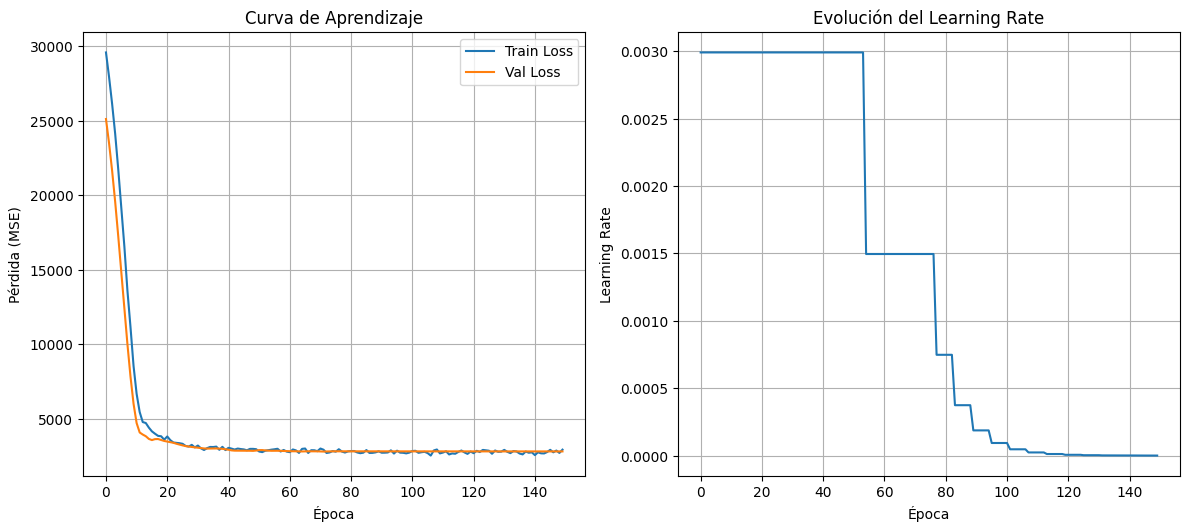

2025-07-29 08:35:29,615 - INFO - Gráfico de curvas de aprendizaje guardado como 'learning_curves.png'


In [9]:
# Gráfico de curvas de aprendizaje
plt.figure(figsize=(12, 10))

# Pérdidas
plt.subplot(2, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Curva de Aprendizaje')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)

# Learning Rate
plt.subplot(2, 2, 2)
plt.plot(learning_rates)
plt.title('Evolución del Learning Rate')
plt.xlabel('Época')
plt.ylabel('Learning Rate')
plt.grid(True)

# Guardar gráficos
plt.tight_layout()
plt.savefig('learning_curves.png')
plt.show()
logger.info("Gráfico de curvas de aprendizaje guardado como 'learning_curves.png'")

## 7. Análisis de Interpretabilidad con SHAP

Utilizamos SHAP (SHapley Additive exPlanations) para entender qué características son más importantes para las predicciones del modelo.

2025-07-29 08:35:33,267 - INFO - 
Calculando importancia de características con SHAP...
/var/folders/ly/g9twzd3d63d1cprw4rh_7z5m0000gn/T/ipykernel_89311/613677437.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test[:50], feature_names=feature_names, show=False)
/Users/leosantucho/miniconda3/envs/machine-learning/lib/python3.13/site-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


<Figure size 1000x800 with 0 Axes>

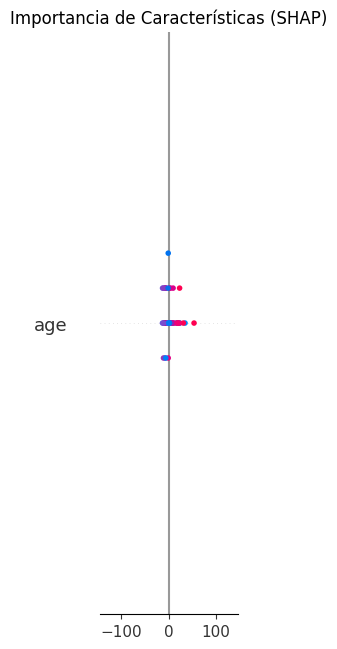

2025-07-29 08:35:33,403 - INFO - Gráfico de importancia SHAP guardado como 'feature_importance_shap.png'


In [10]:
# SHAP para interpretabilidad
try:
    logger.info("\nCalculando importancia de características con SHAP...")
    explainer = shap.DeepExplainer(final_model, X_full_t[:100])
    shap_values = explainer.shap_values(X_test_t[:50])
    
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test[:50], feature_names=feature_names, show=False)
    plt.title('Importancia de Características (SHAP)')
    plt.tight_layout()
    plt.savefig('feature_importance_shap.png')
    plt.show()
    logger.info("Gráfico de importancia SHAP guardado como 'feature_importance_shap.png'")
    
except Exception as e:
    logger.warning(f"No se pudo calcular SHAP: {str(e)}")

## 8. Comparación con Modelos de Machine Learning Tradicionales

Comparamos el rendimiento de nuestra red neuronal con Random Forest y XGBoost.

In [11]:
# Comparación con otros modelos
logger.info("\nEntrenando y evaluando modelos alternativos...")

# Random Forest
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf = RandomForestRegressor(random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='r2')
rf_grid.fit(X_full, y_full)
best_rf = rf_grid.best_estimator_
rf_r2 = best_rf.score(X_test, y_test)
rf_mae = mean_absolute_error(y_test, best_rf.predict(X_test))

logger.info("\nResultados de Random Forest:")
logger.info(f"Mejores parámetros: {rf_grid.best_params_}")
logger.info(f"R²: {rf_r2:.4f}")
logger.info(f"MAE: {rf_mae:.4f}")

2025-07-29 08:35:35,898 - INFO - 
Entrenando y evaluando modelos alternativos...
2025-07-29 08:35:39,747 - INFO - 
Resultados de Random Forest:
2025-07-29 08:35:39,747 - INFO - Mejores parámetros: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
2025-07-29 08:35:39,748 - INFO - R²: 0.4436
2025-07-29 08:35:39,748 - INFO - MAE: 44.0036


In [12]:
# XGBoost
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1]
}

xgb = XGBRegressor(random_state=42)
xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, scoring='r2')
xgb_grid.fit(X_full, y_full)
best_xgb = xgb_grid.best_estimator_
xgb_r2 = best_xgb.score(X_test, y_test)
xgb_mae = mean_absolute_error(y_test, best_xgb.predict(X_test))

logger.info("\nResultados de XGBoost:")
logger.info(f"Mejores parámetros: {xgb_grid.best_params_}")
logger.info(f"R²: {xgb_r2:.4f}")
logger.info(f"MAE: {xgb_mae:.4f}")

2025-07-29 08:35:46,261 - INFO - 
Resultados de XGBoost:
2025-07-29 08:35:46,262 - INFO - Mejores parámetros: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
2025-07-29 08:35:46,262 - INFO - R²: 0.4639
2025-07-29 08:35:46,263 - INFO - MAE: 44.3362


## 9. Resumen de Resultados y Guardado del Modelo

In [14]:
# Resumen comparativo
print("\n" + "="*50)
print("RESUMEN DE RESULTADOS")
print("="*50)
print(f"\nRed Neuronal:")
print(f"  - R² Score: {r2:.4f}")
print(f"  - MAE: {mae:.4f}")
print(f"\nRandom Forest:")
print(f"  - R² Score: {rf_r2:.4f}")
print(f"  - MAE: {rf_mae:.4f}")
print(f"\nXGBoost:")
print(f"  - R² Score: {xgb_r2:.4f}")
print(f"  - MAE: {xgb_mae:.4f}")
print("="*50)


RESUMEN DE RESULTADOS

Red Neuronal:
  - R² Score: 0.4716
  - MAE: 41.8736

Random Forest:
  - R² Score: 0.4436
  - MAE: 44.0036

XGBoost:
  - R² Score: 0.4639
  - MAE: 44.3362


In [15]:
# Guardar modelo final
try:
    torch.save(final_model.state_dict(), 'enhanced_model_diabetes.pth')
    logger.info("Modelo neuronal guardado como 'enhanced_model_diabetes.pth'")
except Exception as e:
    logger.warning(f"No se pudo guardar el modelo: {str(e)}")

logger.info("¡Proceso completado exitosamente!")

2025-07-29 08:35:57,093 - INFO - Modelo neuronal guardado como 'enhanced_model_diabetes.pth'
2025-07-29 08:35:57,094 - INFO - ¡Proceso completado exitosamente!


In [17]:
import torch
import torch.nn as nn
import numpy as np

# ============================
# 🔁 Clase del modelo (Misma que la usada al entrenar)
# ============================

class EnhancedNN(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size, 
                 activation=nn.ReLU, dropout=0.0, use_batchnorm=False):
        super(EnhancedNN, self).__init__()
        layers = []
        in_size = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(in_size, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(activation())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_size = h
        layers.append(nn.Linear(in_size, output_size))
        self.net = nn.Sequential(*layers)  # 🔄 corregido

    def forward(self, x):
        return self.net(x)  # 🔄 corregido

# ============================
# ⚙️ Crear instancia y cargar pesos
# ============================

# Supone que X_test ya está definido
input_size = X_test.shape[1]   # Número de columnas del dataset
hidden_sizes = [64, 32]
output_size = 1
activation = nn.ReLU
dropout = 0.1
use_batchnorm = True

modelo_cargado = EnhancedNN(input_size, hidden_sizes, output_size,
                            activation=activation,
                            dropout=dropout,
                            use_batchnorm=use_batchnorm)

# Cargar pesos desde archivo
modelo_cargado.load_state_dict(torch.load("enhanced_model_diabetes.pth"))
modelo_cargado.eval()

print("✅ Modelo cargado exitosamente.")

# ============================
# 📊 Predicción para nuevo paciente
# ============================

# ⚠️ Debe tener las mismas features que usaste para entrenar (con los mismos preprocesamientos y orden)
# Simulamos un paciente con 10 features de ejemplo:
nuevo_paciente = np.array([[45, 0.05, -0.01, 0.03, 0.02, 0.01, -0.02, 0.01, 0.03, 0.02]])

# Convertir a tensor
nuevo_tensor = torch.tensor(nuevo_paciente, dtype=torch.float32)

# Hacer predicción
with torch.no_grad():
    prediccion = modelo_cargado(nuevo_tensor).item()

print(f"🔮 Predicción para nuevo paciente: {prediccion:.2f}")


RuntimeError: Error(s) in loading state_dict for EnhancedNN:
	Missing key(s) in state_dict: "net.1.weight", "net.1.bias", "net.1.running_mean", "net.1.running_var", "net.4.weight", "net.4.bias", "net.5.weight", "net.5.bias", "net.5.running_mean", "net.5.running_var", "net.8.weight", "net.8.bias". 
	Unexpected key(s) in state_dict: "net.3.weight", "net.3.bias", "net.6.weight", "net.6.bias". 
	size mismatch for net.0.weight: copying a param with shape torch.Size([119, 10]) from checkpoint, the shape in current model is torch.Size([64, 10]).
	size mismatch for net.0.bias: copying a param with shape torch.Size([119]) from checkpoint, the shape in current model is torch.Size([64]).